   Soil_pH  Temperature   Humidity  Wind_Speed     N     P     K  \
0     5.50     9.440599  80.000000   10.956707  60.5  45.0  31.5   
1     6.50    20.052576  79.947424    8.591577  84.0  66.0  50.0   
2     5.50    12.143099  80.000000    7.227751  71.5  54.0  38.5   
3     6.75    19.751848  80.000000    2.682683  50.0  40.0  30.0   
4     5.50    16.110395  80.000000    7.696070  49.5  45.0  38.5   

   Crop_Type_Corn  Crop_Type_Cotton  Crop_Type_Potato  Crop_Type_Rice  \
0           False             False             False           False   
1            True             False             False           False   
2           False             False             False            True   
3           False             False             False           False   
4           False             False             False           False   

   Crop_Type_Soybean  Crop_Type_Sugarcane  Crop_Type_Sunflower  \
0              False                False                False   
1              False

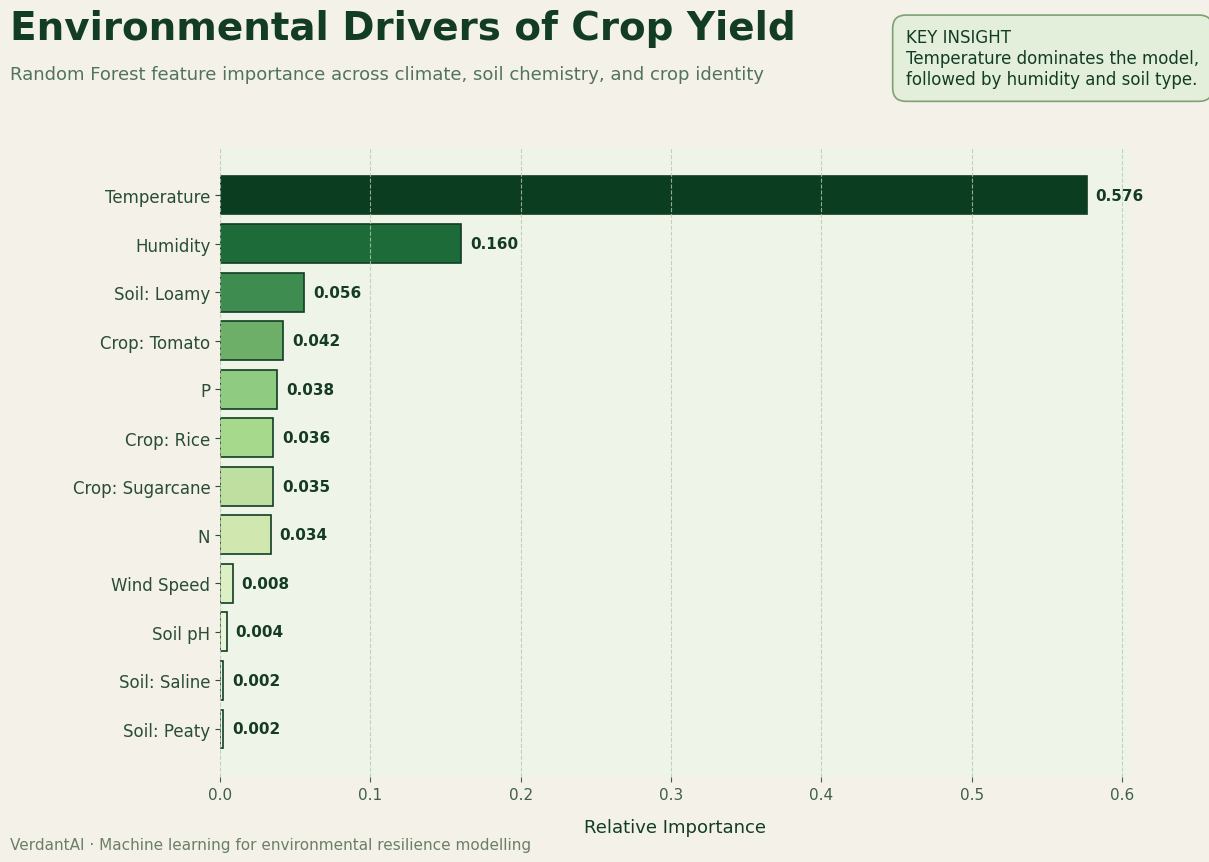

['model.pkl']

In [ ]:
import pandas as pd

df = pd.read_csv("../data/crop_yield_dataset.csv")

X = df.drop(columns=["Crop_Yield", "Date", "Soil_Quality"])
y = df["Crop_Yield"]

X = pd.get_dummies(X, drop_first=True)

print(X.head())

from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores.mean())

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
X = X.astype(int)
print(f"Mean Absolute Error: {mae:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top_features = feature_importance.head(12).copy()

# Clean feature names
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("Crop_Type_", "Crop: ", regex=False)
    .str.replace("Soil_Type_", "Soil: ", regex=False)
    .str.replace("_", " ", regex=False)
)

fig, ax = plt.subplots(figsize=(14, 9))

fig.patch.set_facecolor("#F4F1E8")
ax.set_facecolor("#EEF5E8")

colors = [
    "#0B3D20", "#1E6B3A", "#3E8C4F", "#6DAF68",
    "#8FCB81", "#A7D98C", "#BEDF9F", "#D0E8B0",
    "#DDEFC4", "#E8F5D8", "#EFF8E4", "#F5FAEC"
]

bars = ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors,
    edgecolor="#123D24",
    linewidth=1.2
)

ax.invert_yaxis()

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=11,
        color="#153B25",
        fontweight="bold"
    )

# Titles
fig.text(
    0.08, 0.94,
    "Environmental Drivers of Crop Yield",
    fontsize=28,
    fontweight="bold",
    color="#123D24"
)

fig.text(
    0.08, 0.895,
    "Random Forest feature importance across climate, soil chemistry, and crop identity",
    fontsize=13,
    color="#52735B"
)

# Key insight box
fig.text(
    0.72, 0.89,
    "KEY INSIGHT\nTemperature dominates the model,\nfollowed by humidity and soil type.",
    fontsize=12,
    color="#123D24",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#E3EEDB",
        edgecolor="#7EA172",
        linewidth=1.2
    )
)

ax.set_xlabel("Relative Importance", fontsize=13, color="#123D24", labelpad=12)
ax.set_ylabel("")

ax.tick_params(axis="x", colors="#3F6047", labelsize=11)
ax.tick_params(axis="y", colors="#294D35", labelsize=12)

ax.grid(
    axis="x",
    color="#B7C9AD",
    linestyle="--",
    linewidth=0.8,
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_visible(False)

# Decorative footer
fig.text(
    0.08, 0.04,
    "VerdantAI · Machine learning for environmental resilience modelling",
    fontsize=11,
    color="#6A7F66"
)

plt.subplots_adjust(left=0.23, right=0.88, top=0.82, bottom=0.12)
plt.savefig("../visualisations/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

import joblib

joblib.dump(model, "model.pkl")


